Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



[1] "C"

New names:
• `` -> `...1`


 [1] "...1" "Y3m"  "Y1"   "Y2"   "Y3"   "Y4"   "Y5"   "Y6"   "Y7"   "Y8"  
[11] "Y9"   "Y10" 


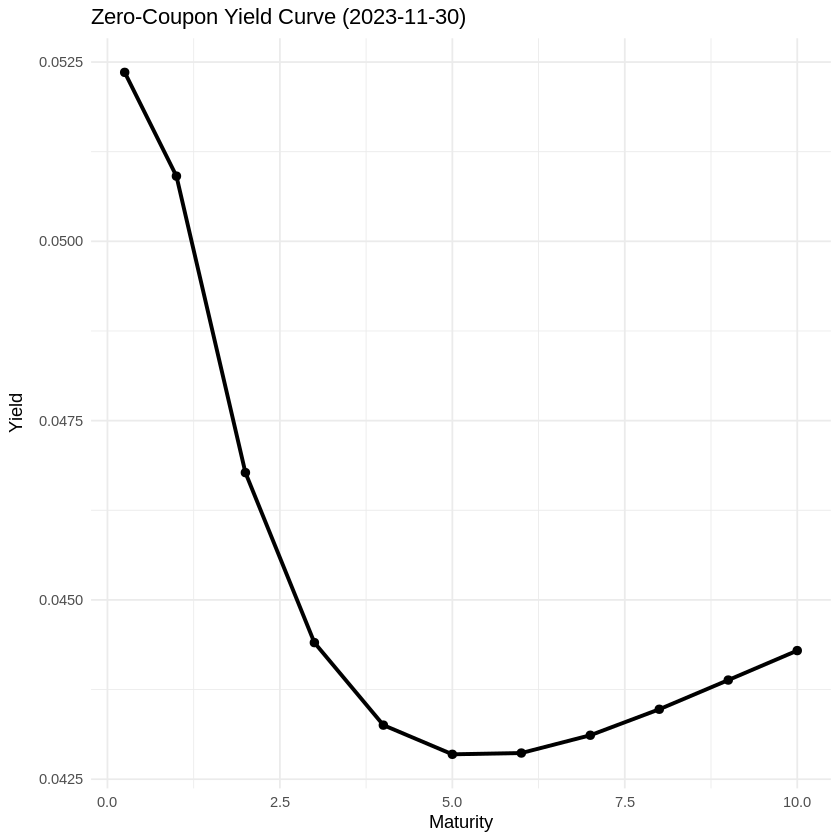

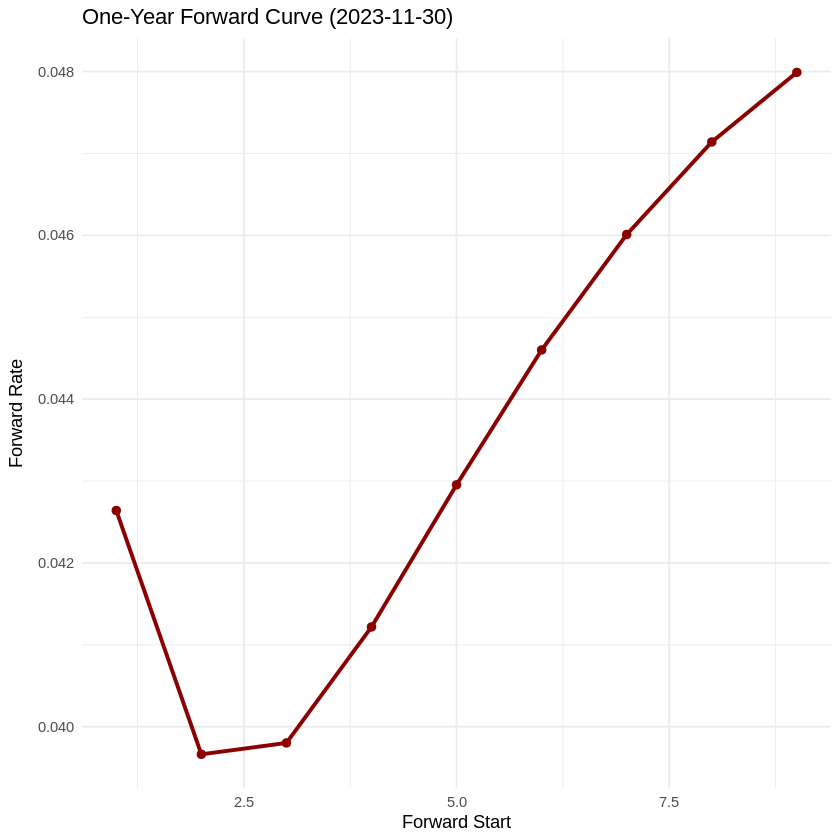

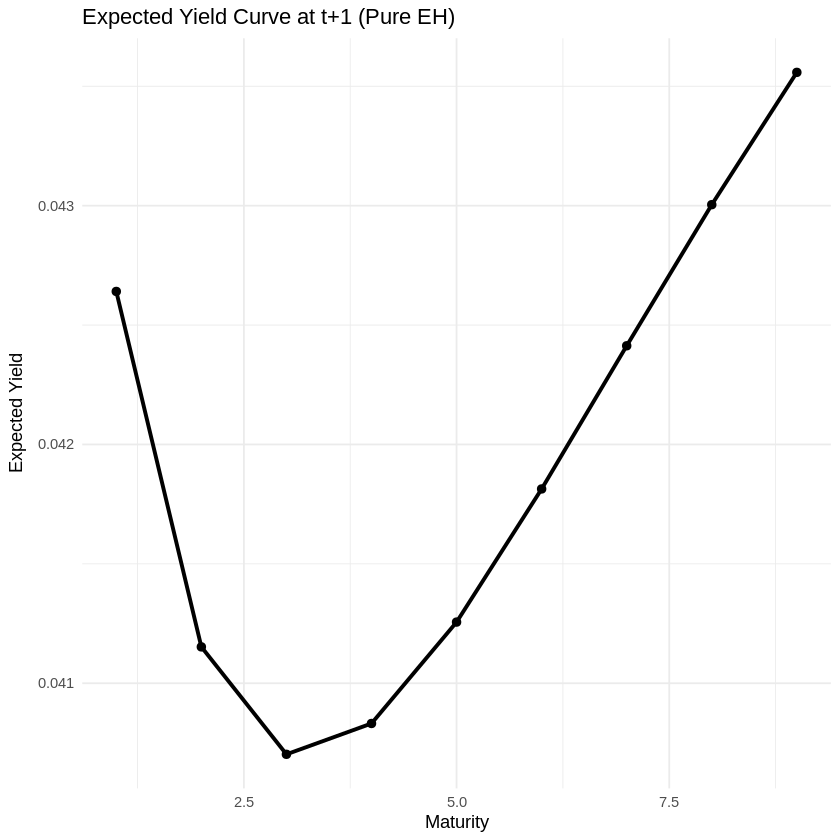

   n             a         b       R2_1             c         d        R2_2
1  2  0.0007780923 0.7472436 0.07465085 -0.0007780923 0.2527564 0.009145737
2  3  0.0001340717 0.9257541 0.08082148 -0.0045060903 0.6295714 0.062007247
3  4 -0.0012359789 1.0854554 0.08816161 -0.0087281686 0.8433442 0.131923367
4  5 -0.0031634561 1.2411175 0.09556090 -0.0106497223 0.8126020 0.142024729
5  6 -0.0054858916 1.3924450 0.10218951 -0.0094326902 0.5912715 0.085810197
6  7 -0.0081321688 1.5434841 0.10806956 -0.0078668644 0.4043973 0.043413252
7  8 -0.0110633784 1.6983427 0.11331773 -0.0078856054 0.3340714 0.029732456
8  9 -0.0142249308 1.8591928 0.11797168 -0.0085801313 0.3034737 0.024396479
9 10 -0.0175361085 2.0265991 0.12203332 -0.0097030509 0.2807216 0.021074515


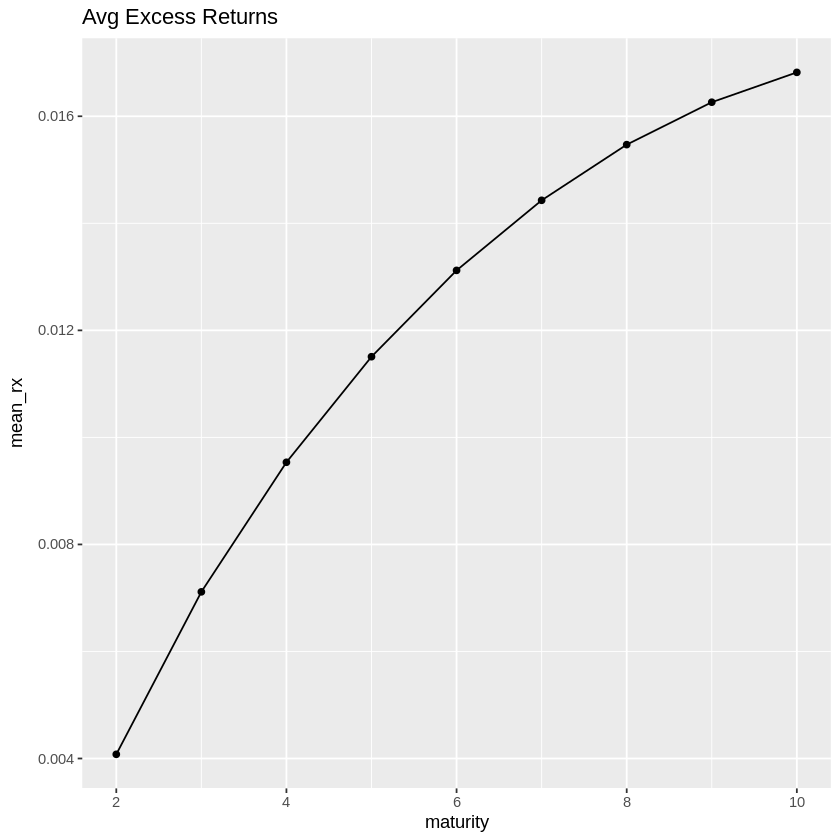

In [ ]:
# === 1. 环境设置与包加载 ===
install.packages("readxl") # Colab R环境有时需要重新安装
library(readxl)
library(dplyr)
library(lubridate)
library(ggplot2)

# 强制设置时间语言环境为英文，确保能识别 "Jun", "Jul" 等月份
Sys.setlocale("LC_TIME", "C")

# === 2. 数据读取 (修正版) ===
# 尝试读取 Excel，如果文件实际上是 CSV (Colab上传转换常见情况)，则用 read.csv
# 注意：skip = 1 是关键，因为第一行是期限数字，第二行才是列名
file_name_xlsx <- "PS1 Data.xlsx"
file_name_csv <- "PS1 Data.xlsx - Sheet1.csv" # 备用文件名

if (file.exists(file_name_xlsx)) {
  df_raw <- read_excel(file_name_xlsx, skip = 1)
} else if (file.exists(file_name_csv)) {
  df_raw <- read.csv(file_name_csv, skip = 1)
} else {
  stop("找不到数据文件，请检查左侧文件栏中上传的文件名")
}

# 检查列名是否正确 (调试用)
print(colnames(df_raw))

# === 3. 数据清洗 ===
# 这里如果不重命名第一列，可能会有乱码或空名，通常第一列是 Date
# 我们假设第一列是日期，将其重命名为 "Date"
colnames(df_raw)[1] <- "Date"

df <- df_raw %>%
  mutate(Date = as.Date(Date, format = "%d-%b-%Y")) %>%
  arrange(Date) # 确保按时间排序

# 检查是否产生了 NA (如果这一步有 NA，说明日期解析失败)
if (any(is.na(df$Date))) {
  warning("警告: 部分日期解析失败，请检查 Date 列格式")
}

# === Question 1: 收益率曲线与远期曲线 ===
yc_20231130 <- df %>%
  filter(Date == as.Date("2023-11-30"))

# 确保找到了这一天的数据
if(nrow(yc_20231130) == 0) stop("错误: 未找到 2023-11-30 的数据，请检查日期列")

maturity <- c(0.25, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10)

yield_20231130 <- tibble(
  maturity = maturity,
  yield = as.numeric(yc_20231130 %>%
                       select(Y3m, Y1, Y2, Y3, Y4, Y5, Y6, Y7, Y8, Y9, Y10))
)

# 计算 Forward (注意：这里使用 Y1 到 Y10 计算 1-9 年后的 1 年期远期利率)
# 对应索引：yield vector中，索引2是Y1，索引3是Y2...
# yield_20231130$yield[2] 是 Y1 (maturity 1)
# yield_20231130$yield[3] 是 Y2 (maturity 2)
forward_20231130 <- tibble(
  maturity = 1:9,
  forward = (2:10) * yield_20231130$yield[3:11] -
            (1:9)  * yield_20231130$yield[2:10]
)

# 绘图 Q1
g1 <- ggplot(yield_20231130, aes(x = maturity, y = yield)) +
  geom_line(linewidth = 1.1) + geom_point(size = 2) +
  labs(title = "Zero-Coupon Yield Curve (2023-11-30)", x = "Maturity", y = "Yield") + theme_minimal()
print(g1)

g2 <- ggplot(forward_20231130, aes(x = maturity, y = forward)) +
  geom_line(linewidth = 1.1, color = "darkred") + geom_point(size = 2, color = "darkred") +
  labs(title = "One-Year Forward Curve (2023-11-30)", x = "Forward Start", y = "Forward Rate") + theme_minimal()
print(g2)


# === Question 2: 预期收益率曲线 (纯预期假说) ===
row_t <- df %>% filter(Date == as.Date("2023-11-30"))

# 提取 Y1 到 Y10
y_vec <- as.numeric(row_t %>% select(Y1:Y10))

# 计算远期利率 f(1, n)
# 公式: f_n = n*y_n - (n-1)*y_{n-1}
# 对应向量操作: (2:10)*y[2:10] - (1:9)*y[1:9]
f <- (2:10) * y_vec[2:10] - (1:9) * y_vec[1:9]

m <- 1:9
i_t <- y_vec[1] # 一年期当前利率
# 纯预期假说: E[y_{t+1}^{(n-1)}] = f_t^{(n)} ? 不完全是，根据你的公式重写：
# 你的公式: E_y_next = y[1:9] + (f - i_t) / m
# 这里的逻辑是基于线性近似或其他推导，保持原样
E_y_next <- y_vec[1:9] + (f - i_t) / m

plot_df <- data.frame(maturity = m, exp_yield = E_y_next)

g3 <- ggplot(plot_df, aes(x = maturity, y = exp_yield)) +
  geom_line(linewidth = 1.1) + geom_point(size = 2) +
  labs(title = "Expected Yield Curve at t+1 (Pure EH)", x = "Maturity", y = "Expected Yield") + theme_minimal()
print(g3)


# === Question 4: Excess Returns & Spreads ===
df2 <- df %>% arrange(Date)
y_cols <- paste0("Y", 1:10)
Y <- as.matrix(df2[, y_cols])

# 计算对数价格 p = -n * y
n_vec <- 1:10
P <- sweep(Y, 2, n_vec, FUN = function(y, n) -n * y)

h <- 12 # 假设数据是月度的，持有期1年=12个月
Tn <- nrow(df2)
idx  <- 1:(Tn - h)     # 当前时间 t
idx1 <- (1 + h):Tn     # 未来时间 t+1 (即 t+12个月)

# 计算持有期回报: r_{t+1}^{(n)} = p_{t+1}^{(n-1)} - p_t^{(n)}
# P[idx1, 1:9] 是 p_{t+1} 的 n=1..9 (对应原债券 n=2..10 变成 n-1)
# P[idx, 2:10] 是 p_t 的 n=2..10
R <- matrix(NA_real_, nrow = Tn, ncol = 9)
colnames(R) <- paste0("r_", 2:10)
R[idx, ] <- P[idx1, 1:9] - P[idx, 2:10]

# 超额回报 rx = r - i_t
i_t <- Y[, 1] # Y1
RX <- matrix(NA_real_, nrow = Tn, ncol = 9)
colnames(RX) <- paste0("rx_", 2:10)
RX[idx, ] <- R[idx, ] - i_t[idx]

# 计算 Forward Rates 和 Spread
# F矩阵维度与RX一致 (f_2 到 f_10)
F_mat <- matrix(NA_real_, nrow = Tn, ncol = 9)
colnames(F_mat) <- paste0("f_", 2:10)
# F计算不依赖跨期，全样本可算
F_mat[,] <- sweep(Y[, 2:10], 2, 2:10, `*`) - sweep(Y[, 1:9], 2, 1:9, `*`)

SPREAD <- matrix(NA_real_, nrow = Tn, ncol = 9)
colnames(SPREAD) <- paste0("fs_", 2:10)
SPREAD[,] <- F_mat - i_t

# 统计量
sum_df <- data.frame(
  maturity = 2:10,
  mean_rx  = colMeans(RX, na.rm = TRUE),
  sd_rx    = apply(RX, 2, sd, na.rm = TRUE),
  mean_fs  = colMeans(SPREAD, na.rm = TRUE)
)
sum_df$sharpe <- sum_df$mean_rx / sum_df$sd_rx

# 绘图 Q4 (示例画一个)
g4 <- ggplot(sum_df, aes(x = maturity, y = mean_rx)) +
  geom_line() + geom_point() + labs(title = "Avg Excess Returns")
print(g4)


# === Question 5: Regressions ===
res <- data.frame(
  n = 2:10,
  a = NA_real_, b = NA_real_, R2_1 = NA_real_,
  c = NA_real_, d = NA_real_, R2_2 = NA_real_
)

for (k in 1:9) {
  n <- k + 1 # 实际期限 2 到 10

  # --- Regression 1: Forecast Excess Returns ---
  # rx_{t+1} = a + b * spread_t
  x1 <- SPREAD[, k]
  y1 <- RX[, k]
  # lm 会自动处理 NA (RX尾部有NA)
  fit1 <- lm(y1 ~ x1)
  res$a[k]    <- coef(fit1)[1]
  res$b[k]    <- coef(fit1)[2]
  res$R2_1[k] <- summary(fit1)$r.squared

  # --- Regression 2: Forecast Yield Changes ---
  # y_{t+n-1}^{(1)} - y_t^{(1)} = c + d * spread_t
  # Lead time: n-1 年. 数据是月度，所以 lead = 12 * (n-1)
  lead <- 12 * (n - 1)

  # 确保索引不越界
  if (Tn > lead) {
    # y2: 未来收益率变动
    y2_future <- Y[(1 + lead):Tn, 1]
    y2_current <- Y[1:(Tn - lead), 1]
    y2 <- y2_future - y2_current

    # x2: 当前 Spread (对应时间对齐)
    x2 <- SPREAD[1:(Tn - lead), k]

    fit2 <- lm(y2 ~ x2)
    res$c[k]    <- coef(fit2)[1]
    res$d[k]    <- coef(fit2)[2]
    res$R2_2[k] <- summary(fit2)$r.squared
  }
}

print(res)
write.csv(res, "Q5_results.csv", row.names = FALSE)

In [ ]:
# === Question 9: Split sample into pre-1985 and post-1985 ===

# 1) 定义分样本切点
cut_date <- as.Date("1985-01-01")

# 注意：RX 和 SPREAD 是矩阵（长度 Tn），df2$Date 对应同样长度
dates <- df2$Date

# pre: Date < 1985-01-01
# post: Date >= 1985-01-01
idx_pre  <- which(dates < cut_date)
idx_post <- which(dates >= cut_date)

# 2) 写一个函数：给定一个样本索引集合，跑两组回归并返回结果表
run_fama_bliss_split <- function(sample_idx, label) {
  out <- data.frame(
    sample = label,
    n = 2:10,
    a = NA_real_, b = NA_real_, R2_1 = NA_real_,
    c = NA_real_, d = NA_real_, R2_2 = NA_real_
  )

  # Regression 1 uses one-year-ahead excess returns (12 months)
  # Regression 2 uses (n-1)-year-ahead changes in 1y yield -> needs lead = 12*(n-1)

  for (k in 1:9) {
    n <- k + 1

    # --- Regression 1: rx_{t+12}^{(n)} on spread_t ---
    x1 <- SPREAD[sample_idx, k]
    y1 <- RX[sample_idx, k]

    fit1 <- lm(y1 ~ x1)  # lm will drop NA automatically
    out$a[k]    <- coef(fit1)[1]
    out$b[k]    <- coef(fit1)[2]
    out$R2_1[k] <- summary(fit1)$r.squared

    # --- Regression 2: y_{t+12*(n-1)}^1 - y_t^1 on spread_t ---
    lead <- 12 * (n - 1)

    # 为了对齐：t 必须保证 t+lead 在样本内
    # 我们只使用 sample_idx 中那些满足 (i + lead) <= Tn 的点
    valid_t <- sample_idx[sample_idx + lead <= Tn]

    if (length(valid_t) > 10) {  # 防止样本太少
      y2 <- Y[valid_t + lead, 1] - Y[valid_t, 1]
      x2 <- SPREAD[valid_t, k]

      fit2 <- lm(y2 ~ x2)
      out$c[k]    <- coef(fit2)[1]
      out$d[k]    <- coef(fit2)[2]
      out$R2_2[k] <- summary(fit2)$r.squared
    }
  }

  return(out)
}

# 3) 分别跑 pre 和 post
res_pre  <- run_fama_bliss_split(idx_pre,  "pre_1985")
res_post <- run_fama_bliss_split(idx_post, "post_1985")

# 4) 合并并展示
res_q9 <- rbind(res_pre, res_post)
res_q9_round <- res_q9
res_q9_round[, -c(1,2)] <- round(res_q9_round[, -c(1,2)], 7)
print(res_q9_round)

cat("\n  ====================== PRE 1985 ===============================\n")
print(round(res_pre[, -1], 7))   # 去掉 sample 列

cat("\n  ====================== POST 1985 ==============================\n")
print(round(res_post[, -1], 7))  # 去掉 sample 列

# 5) 保存为 CSV
write.csv(res_q9, "Q9_split_sample_results.csv", row.names = FALSE)

      sample  n          a         b      R2_1          c         d      R2_2
1   pre_1985  2 -0.0020635 0.9335926 0.1133205  0.0020635 0.0664074 0.0006462
2   pre_1985  3 -0.0050441 1.0287089 0.0875987  0.0014283 0.4874961 0.0339751
3   pre_1985  4 -0.0082072 1.0982891 0.0688970  0.0006425 0.8676003 0.1018422
4   pre_1985  5 -0.0115775 1.1863587 0.0576620  0.0004013 1.1929553 0.1672151
5   pre_1985  6 -0.0151153 1.2930774 0.0510662  0.0014125 1.3009788 0.1820501
6   pre_1985  7 -0.0188159 1.4189075 0.0475486  0.0023086 1.3486276 0.1848186
7   pre_1985  8 -0.0226813 1.5653079 0.0461317  0.0026631 1.3070181 0.1608203
8   pre_1985  9 -0.0266882 1.7319972 0.0461073  0.0033043 1.0603476 0.0959130
9   pre_1985 10 -0.0307783 1.9168098 0.0469555  0.0022138 0.9539984 0.0689048
10 post_1985  2  0.0036332 0.4491056 0.0281643 -0.0036332 0.5508944 0.0417839
11 post_1985  3  0.0054767 0.6626145 0.0451324 -0.0110013 0.9641472 0.1450566
12 post_1985  4  0.0066509 0.8051525 0.0542539 -0.0200871 1.2333

Installing package into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)



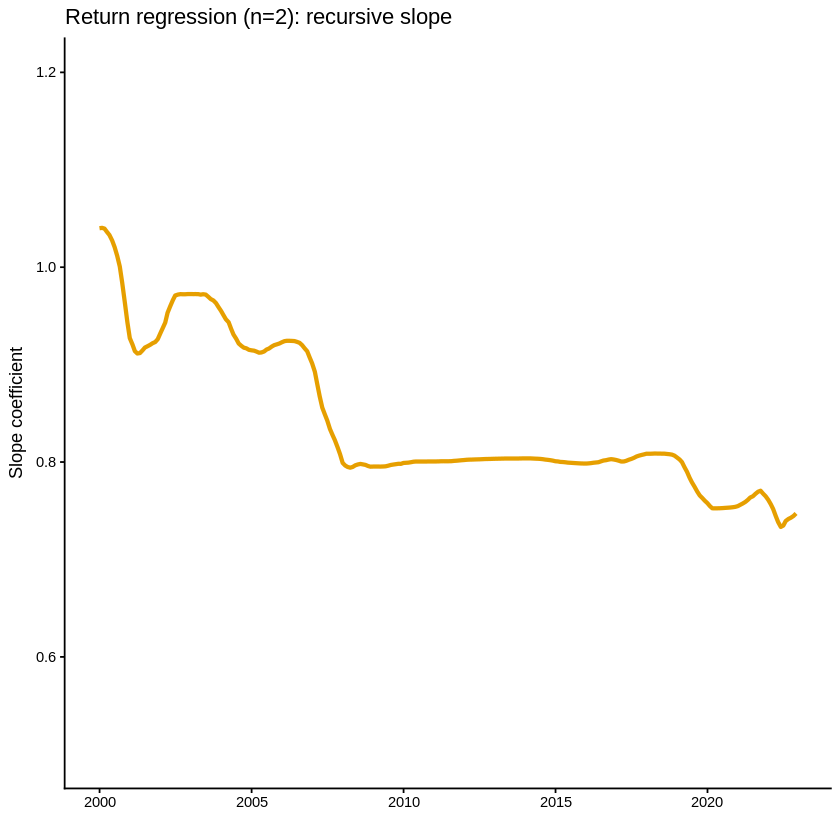

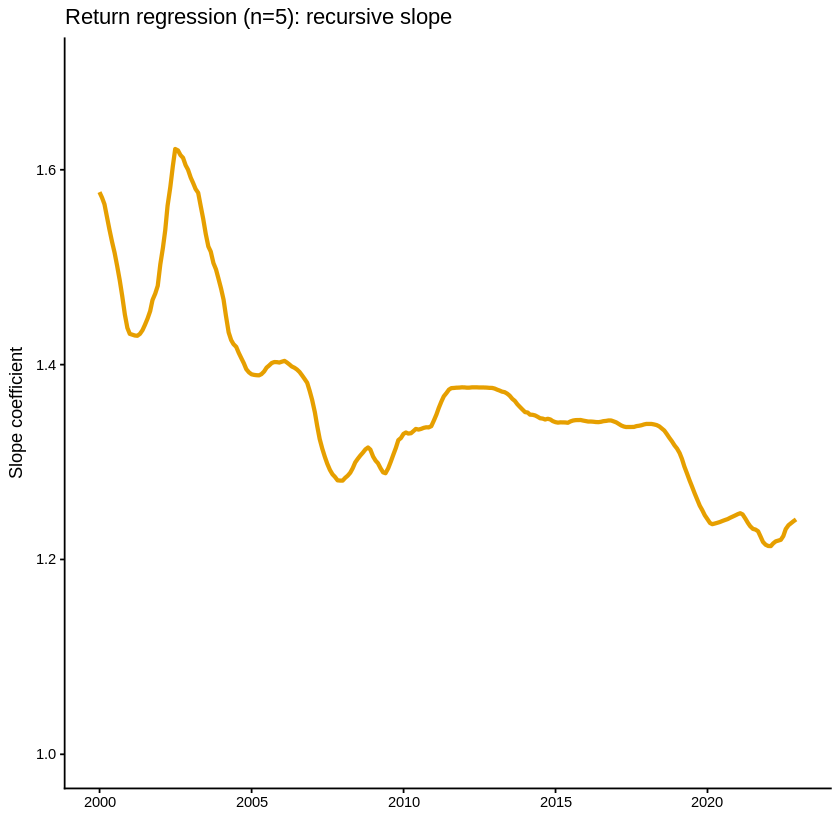

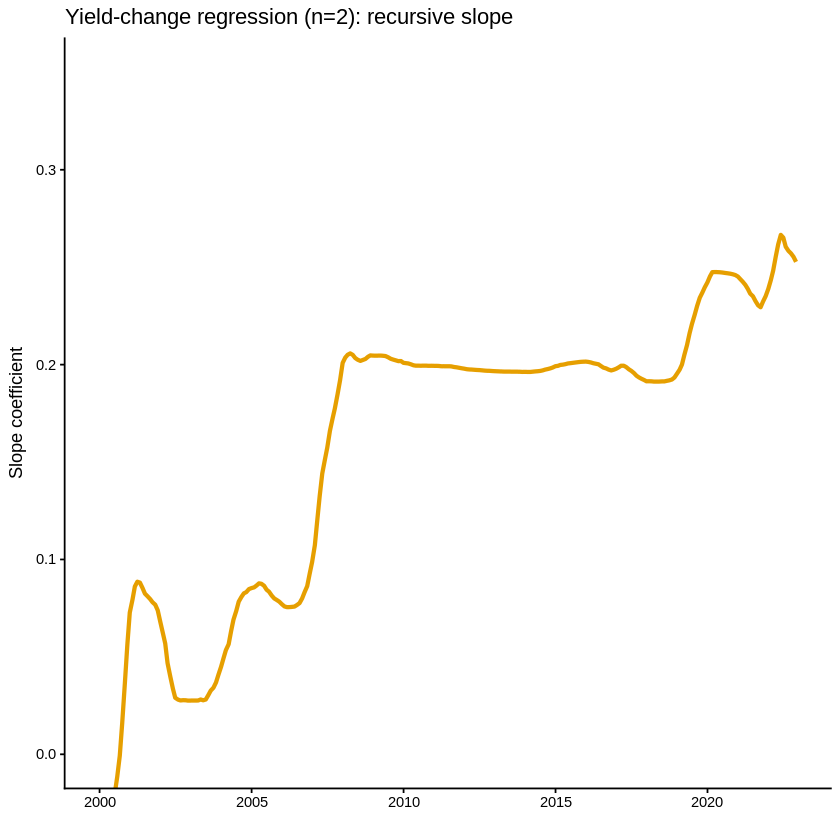

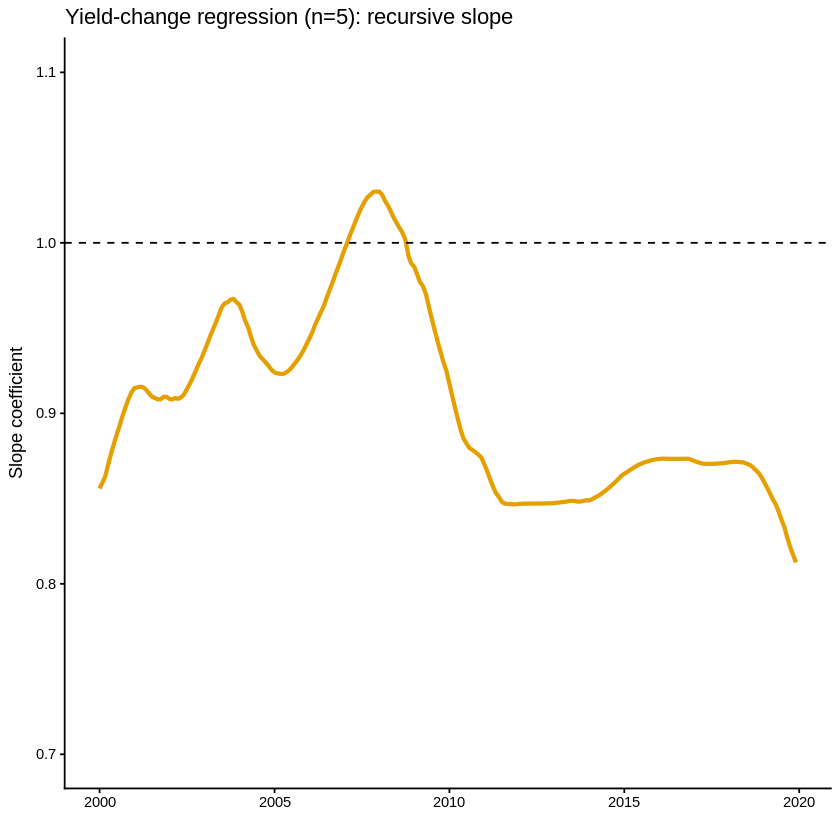

In [ ]:
# ==========================================================
# Question 10:
# ==========================================================
install.packages("tidyr")
library(tidyr)

library(ggplot2)
library(lubridate)

# ----------------------------------------------------------
# 1) Define starting point (Dec 1999)
# ----------------------------------------------------------
start_idx <- which(year(df2$Date) == 1999 &
                   month(df2$Date) == 12)[1]

if(is.na(start_idx)){
  stop("找不到 1999年12月的数据")
}

Tn <- nrow(df2)

# ----------------------------------------------------------
# 2) Recursive Return Regression
#    rx_{t+1} = a + b * spread_t
# ----------------------------------------------------------
recursive_return <- function(k){

  b_series <- rep(NA_real_, Tn)

  for(t in start_idx:(Tn - 12)){

    sample_range <- 1:t

    x <- SPREAD[sample_range, k]
    y <- RX[sample_range, k]

    fit <- lm(y ~ x)

    b_series[t] <- coef(fit)[2]
  }

  return(b_series)
}

# ----------------------------------------------------------
# 3) Recursive Yield-Change Regression
#    y_{t+12(n-1)}^1 - y_t^1 = c + d * spread_t
# ----------------------------------------------------------
recursive_yield <- function(k){

  n    <- k + 1
  lead <- 12 * (n - 1)

  d_series <- rep(NA_real_, Tn)

  for(t in start_idx:(Tn - lead)){

    sample_range <- 1:t
    valid        <- sample_range[sample_range + lead <= Tn]

    if(length(valid) > 30){

      y2 <- Y[valid + lead, 1] - Y[valid, 1]
      x2 <- SPREAD[valid, k]

      fit <- lm(y2 ~ x2)

      d_series[t] <- coef(fit)[2]
    }
  }

  return(d_series)
}

# ----------------------------------------------------------
# 4) Run for n = 2 and n = 5
# ----------------------------------------------------------
# n = 2  → k = 1
b2 <- recursive_return(1)
d2 <- recursive_yield(1)

# n = 5  → k = 4
b5 <- recursive_return(4)
d5 <- recursive_yield(4)

# ----------------------------------------------------------
# 5) Create dataframe
# ----------------------------------------------------------
plot_df <- data.frame(
  Date = df2$Date,
  b2   = b2,
  b5   = b5,
  d2   = d2,
  d5   = d5
)

# ----------------------------------------------------------
# 6) Plot 1: Return regression n=2
# ----------------------------------------------------------
plot_r2 <- plot_df %>%
  filter(Date >= as.Date("1999-12-01"),
         !is.na(b2))

g_r2 <- ggplot(plot_r2, aes(x = Date, y = b2)) +
  geom_line(color = "#E69F00", linewidth = 1.2) +
  geom_hline(yintercept = 0, linetype = "dashed", color="black") +
  coord_cartesian(ylim = c(0.5, 1.2)) +
  labs(title = "Return regression (n=2): recursive slope",
       y = "Slope coefficient",
       x = "") +
  theme_classic()

print(g_r2)


# ----------------------------------------------------------
# 7) Plot 2: Return regression n=5
# ----------------------------------------------------------
plot_r5 <- plot_df %>%
  filter(Date >= as.Date("1999-12-01"),
         !is.na(b5))

g_r5 <- ggplot(plot_r5, aes(x = Date, y = b5)) +
  geom_line(color = "#E69F00", linewidth = 1.2) +
  geom_hline(yintercept = 0, linetype = "dashed") +
  coord_cartesian(ylim = c(1.0, 1.7)) +
  labs(title = "Return regression (n=5): recursive slope",
       y = "Slope coefficient",
       x = "") +
  theme_classic()

print(g_r5)


# ----------------------------------------------------------
# 8) Plot 3: Yield-change regression n=2
# ----------------------------------------------------------
plot_y2 <- plot_df %>%
  filter(Date >= as.Date("1999-12-01"),
         !is.na(d2))

g_y2 <- ggplot(plot_y2, aes(x = Date, y = d2)) +
  geom_line(color = "#E69F00", linewidth = 1.2) +
  geom_hline(yintercept = 1, linetype = "dashed") +
  coord_cartesian(ylim = c(0, 0.35)) +
  labs(title = "Yield-change regression (n=2): recursive slope",
       y = "Slope coefficient",
       x = "") +
  theme_classic()

print(g_y2)


# ----------------------------------------------------------
# 9) Plot 4: Yield-change regression n=5
# ----------------------------------------------------------
plot_y5 <- plot_df %>%
  filter(Date >= as.Date("1999-12-01"),
         !is.na(d5))

g_y5 <- ggplot(plot_y5, aes(x = Date, y = d5)) +
  geom_line(color = "#E69F00", linewidth = 1.2) +
  geom_hline(yintercept = 1, linetype = "dashed") +
  coord_cartesian(ylim = c(0.7, 1.1)) +
  labs(title = "Yield-change regression (n=5): recursive slope",
       y = "Slope coefficient",
       x = "") +
  theme_classic()

print(g_y5)

# ----------------------------------------------------------
# 10) Save figures
# ----------------------------------------------------------
ggsave("Q10_return_n2.png", g_r2, width = 8, height = 5)
ggsave("Q10_return_n5.png", g_r5, width = 8, height = 5)
ggsave("Q10_yield_n2.png",  g_y2, width = 8, height = 5)
ggsave("Q10_yield_n5.png",  g_y5, width = 8, height = 5)


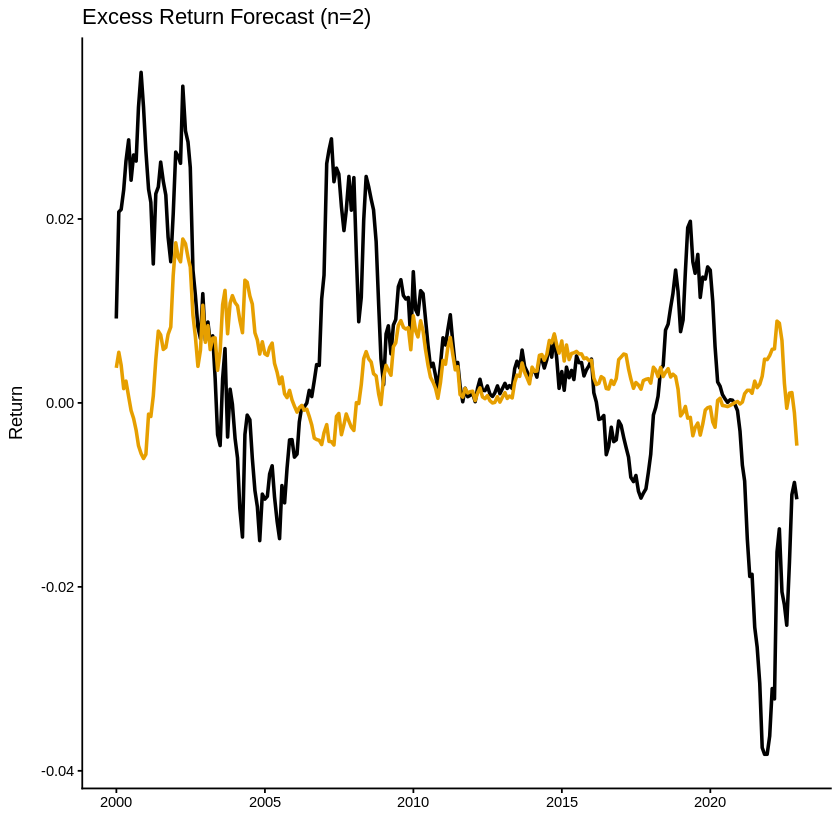

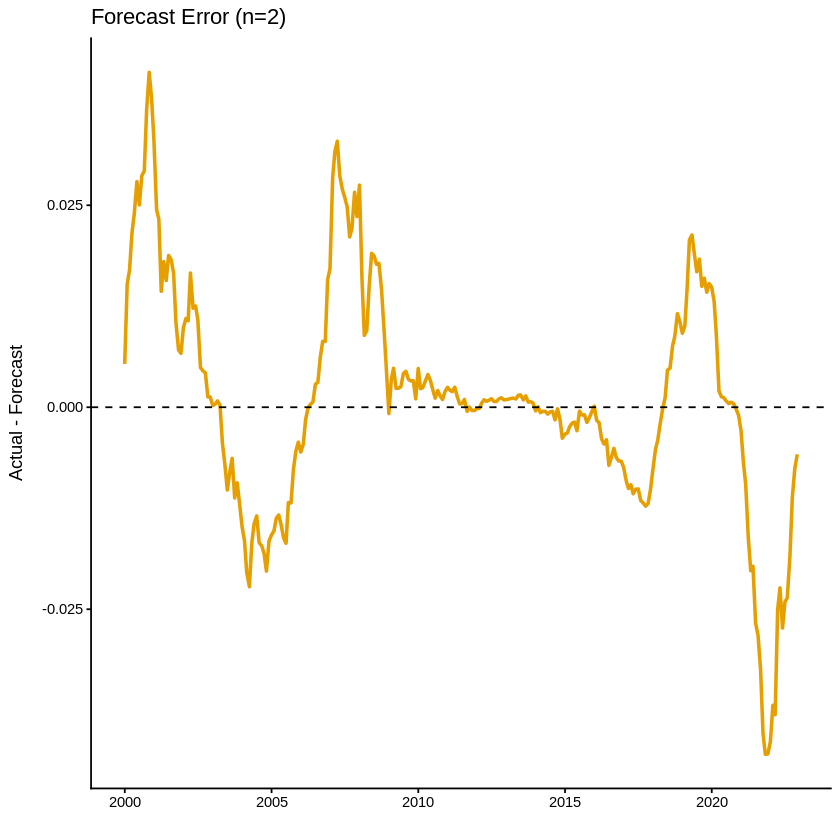

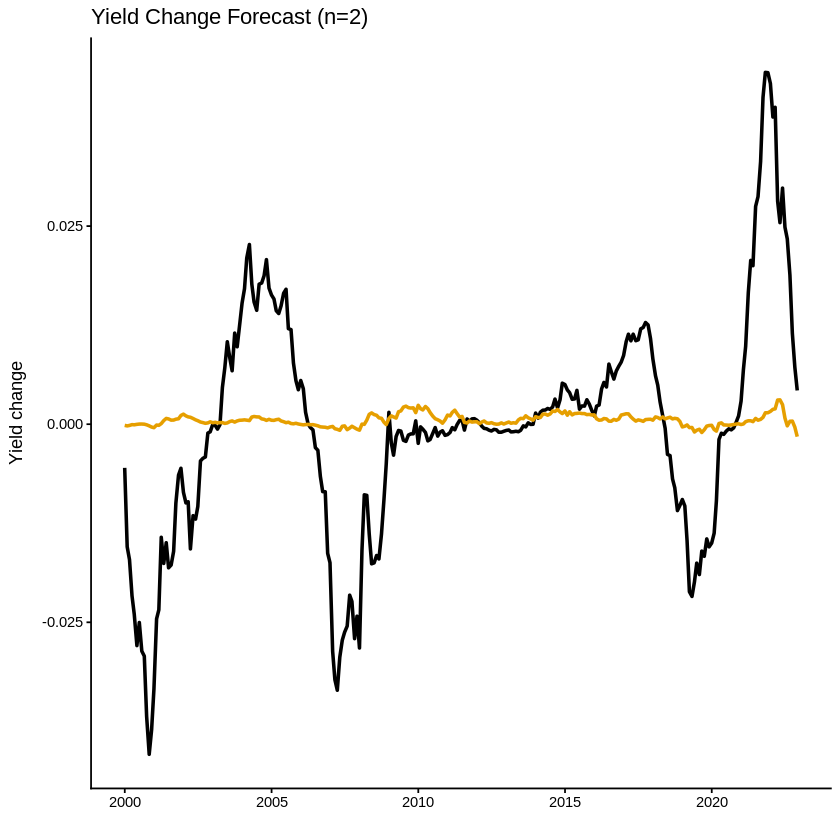

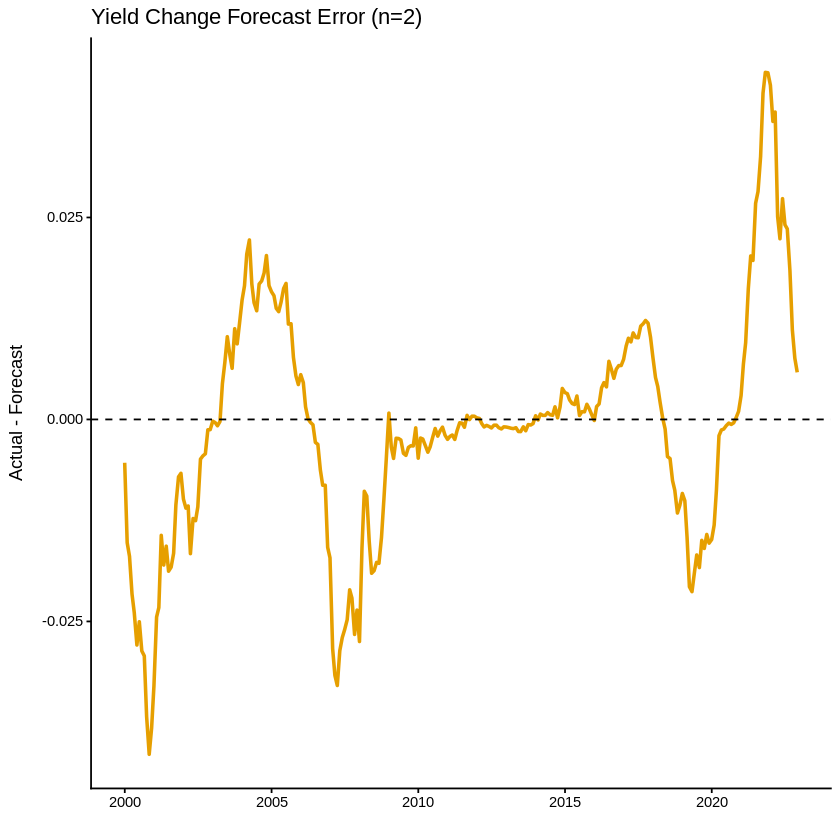

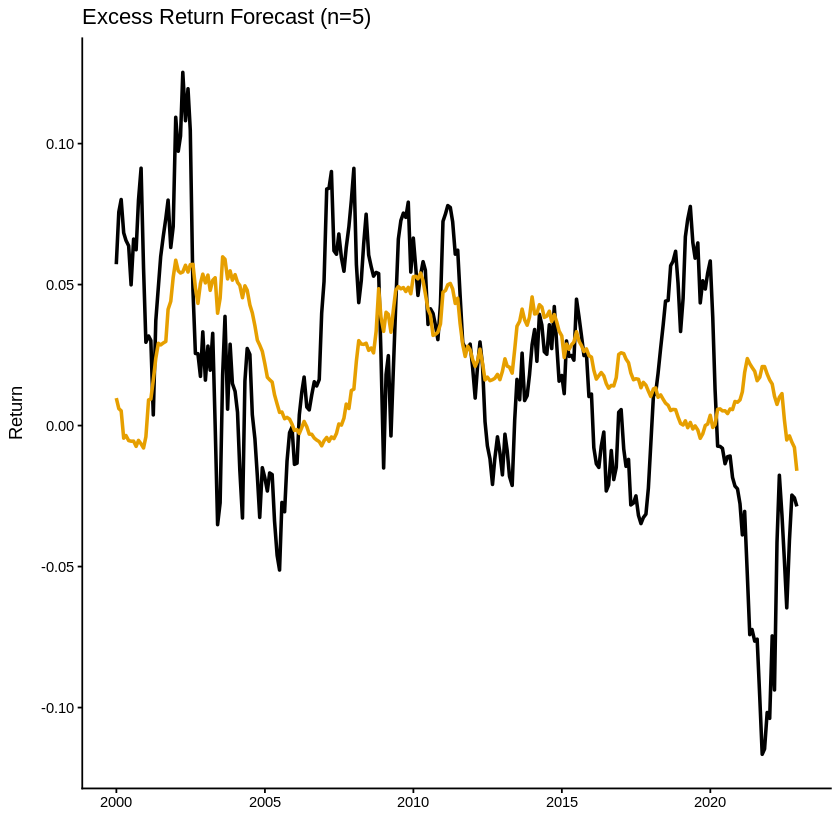

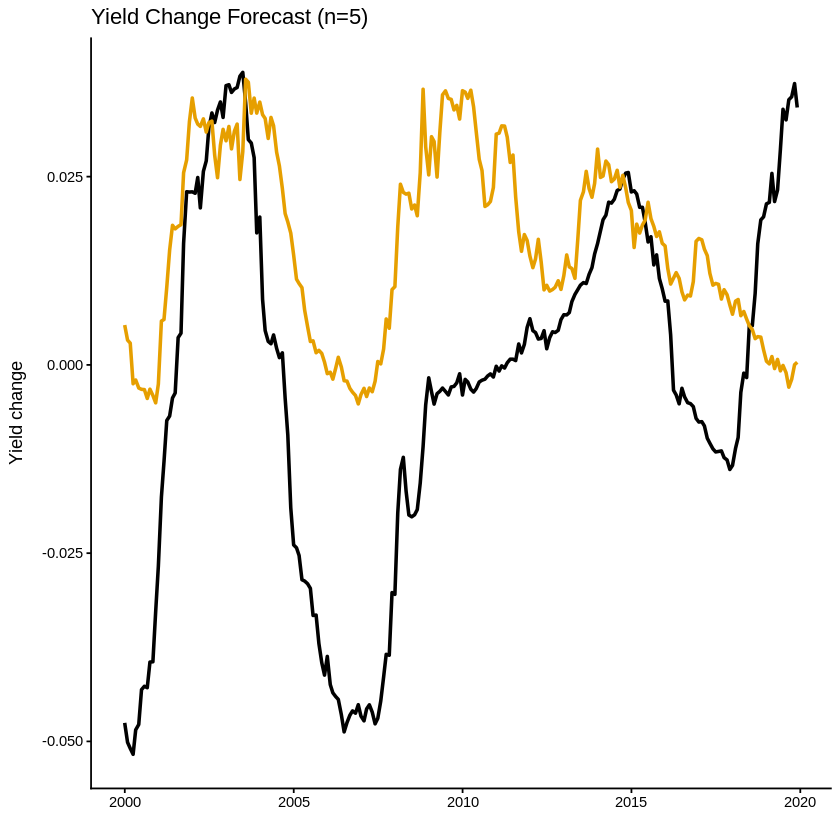

In [ ]:
# ==========================================================
# Question 11: OOS Forecasts
# ==========================================================

library(ggplot2)
library(dplyr)
library(lubridate)

start_date <- as.Date("1999-12-01")

# ==========================================================
# 1) Build Forecast Series
# ==========================================================

# -------- Excess Returns --------

# n = 2
rx2_actual   <- RX[,1]
rx2_forecast <- b2 * SPREAD[,1]
rx2_error    <- rx2_actual - rx2_forecast

# n = 5
rx5_actual   <- RX[,4]
rx5_forecast <- b5 * SPREAD[,4]
rx5_error    <- rx5_actual - rx5_forecast


# -------- Yield Changes --------

# n = 2
lead2 <- 12
dy2_actual <- rep(NA_real_, Tn)
dy2_actual[1:(Tn-lead2)] <- Y[(1+lead2):Tn,1] - Y[1:(Tn-lead2),1]
dy2_forecast <- d2 * SPREAD[,1]
dy2_error    <- dy2_actual - dy2_forecast

# n = 5
lead5 <- 48
dy5_actual <- rep(NA_real_, Tn)
dy5_actual[1:(Tn-lead5)] <- Y[(1+lead5):Tn,1] - Y[1:(Tn-lead5),1]
dy5_forecast <- d5 * SPREAD[,4]
dy5_error    <- dy5_actual - dy5_forecast


# ==========================================================
# 2) Combine into DataFrame
# ==========================================================

forecast_df <- data.frame(
  Date = df2$Date,
  rx2_actual, rx2_forecast, rx2_error,
  rx5_actual, rx5_forecast, rx5_error,
  dy2_actual, dy2_forecast, dy2_error,
  dy5_actual, dy5_forecast, dy5_error
) %>%
  filter(Date >= start_date)


# ==========================================================
# 3) Excess Return Forecast (n=2)
# ==========================================================

plot_rx2 <- forecast_df %>%
  filter(!is.na(rx2_actual))

g_rx2 <- ggplot(plot_rx2, aes(x = Date)) +
  geom_line(aes(y = rx2_actual), color="black", linewidth=1) +
  geom_line(aes(y = rx2_forecast), color="#E69F00", linewidth=1) +
  labs(title="Excess Return Forecast (n=2)",
       y="Return", x="") +
  theme_classic()

print(g_rx2)


# Forecast Error
g_rx2_error <- ggplot(plot_rx2, aes(x = Date, y = rx2_error)) +
  geom_line(color="#E69F00", linewidth=1) +
  geom_hline(yintercept=0, linetype="dashed") +
  labs(title="Forecast Error (n=2)",
       y="Actual - Forecast", x="") +
  theme_classic()

print(g_rx2_error)


# ==========================================================
# 4) Yield Change Forecast (n=2)
# ==========================================================

plot_dy2 <- forecast_df %>%
  filter(!is.na(dy2_actual))

g_dy2 <- ggplot(plot_dy2, aes(x = Date)) +
  geom_line(aes(y = dy2_actual), color="black", linewidth=1) +
  geom_line(aes(y = dy2_forecast), color="#E69F00", linewidth=1) +
  labs(title="Yield Change Forecast (n=2)",
       y="Yield change", x="") +
  theme_classic()

print(g_dy2)


# Forecast Error
g_dy2_error <- ggplot(plot_dy2, aes(x = Date, y = dy2_error)) +
  geom_line(color="#E69F00", linewidth=1) +
  geom_hline(yintercept=0, linetype="dashed") +
  labs(title="Yield Change Forecast Error (n=2)",
       y="Actual - Forecast", x="") +
  theme_classic()

print(g_dy2_error)


# ==========================================================
# 5) n=5 Versions
# ==========================================================

plot_rx5 <- forecast_df %>%
  filter(!is.na(rx5_actual))

g_rx5 <- ggplot(plot_rx5, aes(x = Date)) +
  geom_line(aes(y = rx5_actual), color="black", linewidth=1) +
  geom_line(aes(y = rx5_forecast), color="#E69F00", linewidth=1) +
  labs(title="Excess Return Forecast (n=5)",
       y="Return", x="") +
  theme_classic()

print(g_rx5)


plot_dy5 <- forecast_df %>%
  filter(!is.na(dy5_actual))

g_dy5 <- ggplot(plot_dy5, aes(x = Date)) +
  geom_line(aes(y = dy5_actual), color="black", linewidth=1) +
  geom_line(aes(y = dy5_forecast), color="#E69F00", linewidth=1) +
  labs(title="Yield Change Forecast (n=5)",
       y="Yield change", x="") +
  theme_classic()

print(g_dy5)



==================== Question 12 ====================
OOS evaluation starts at: 1999-12-01 
Number of OOS months (forecast_df): 288 



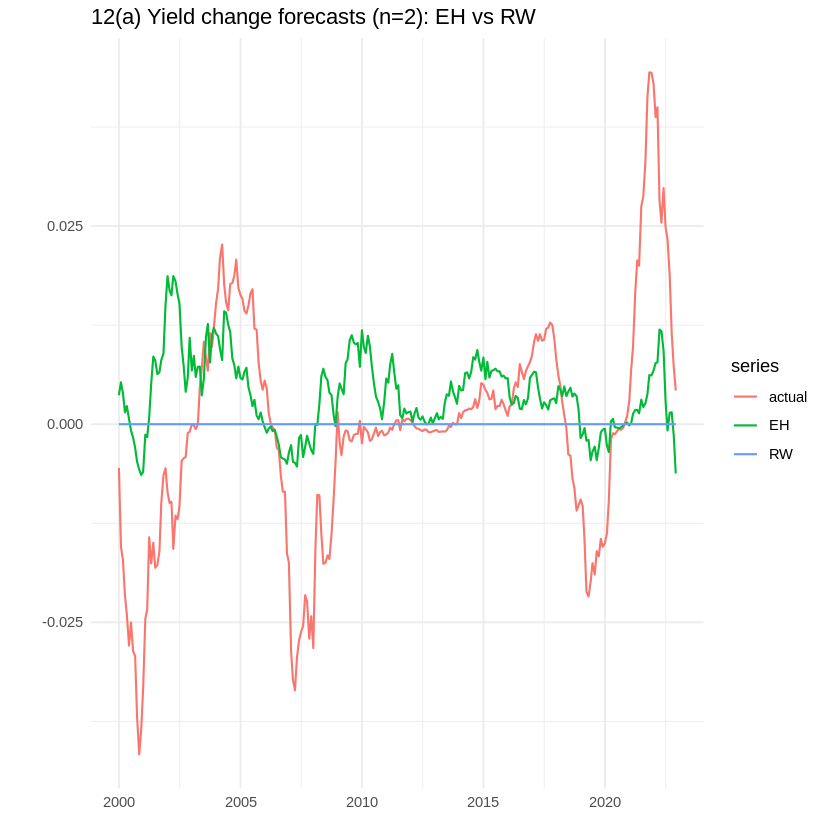

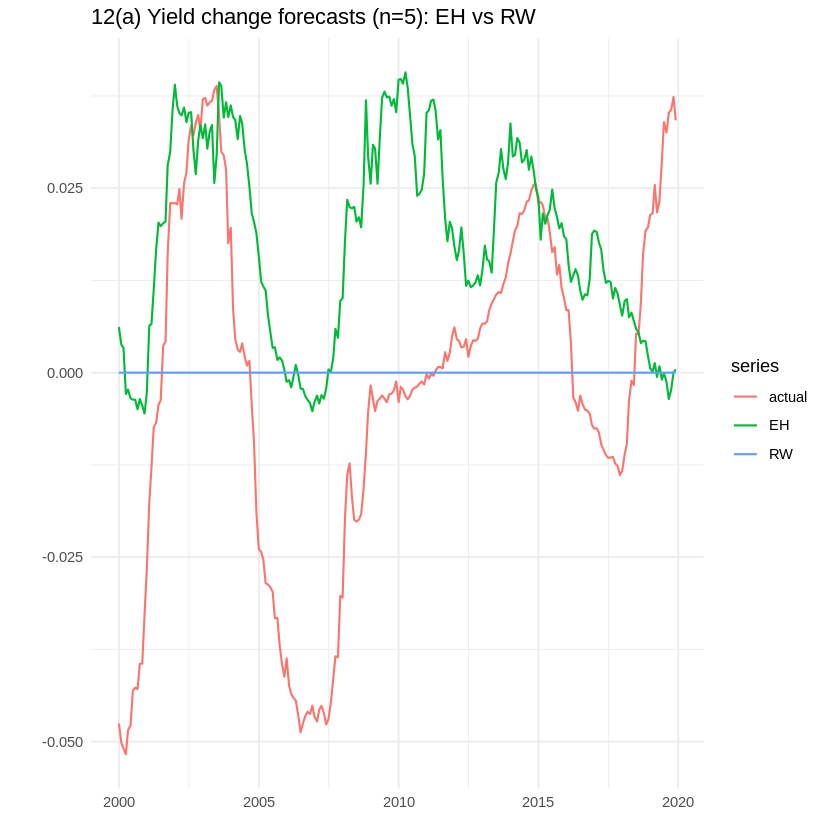

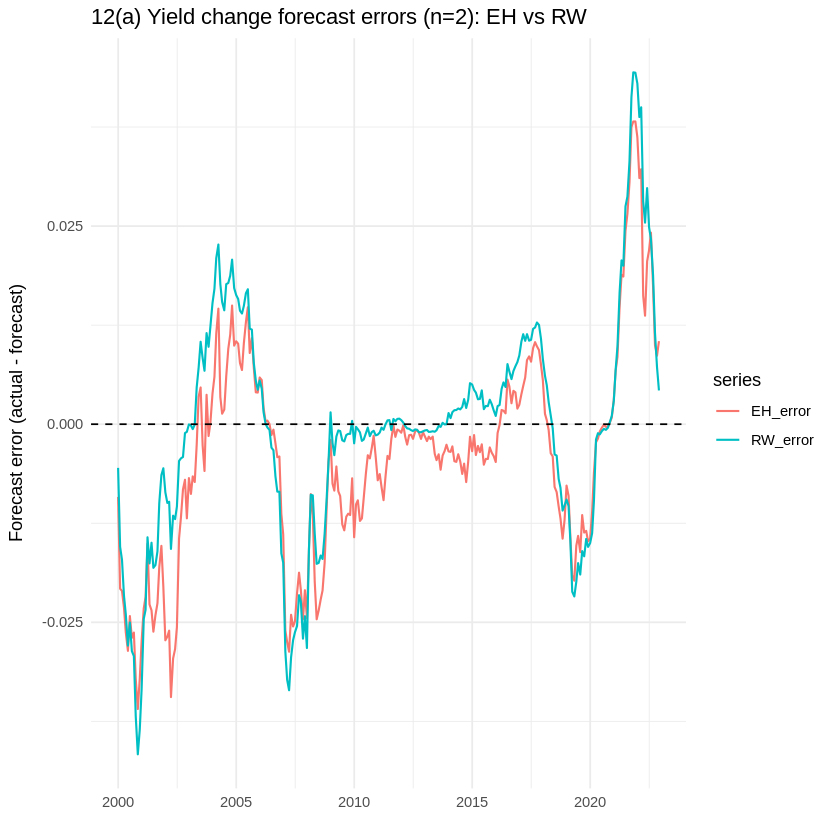

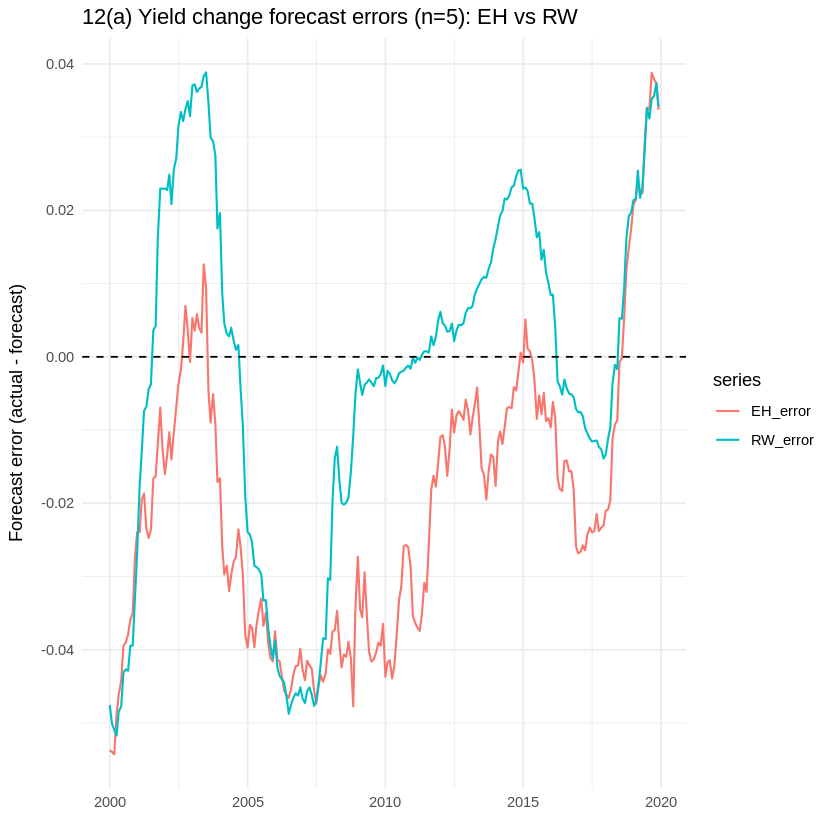

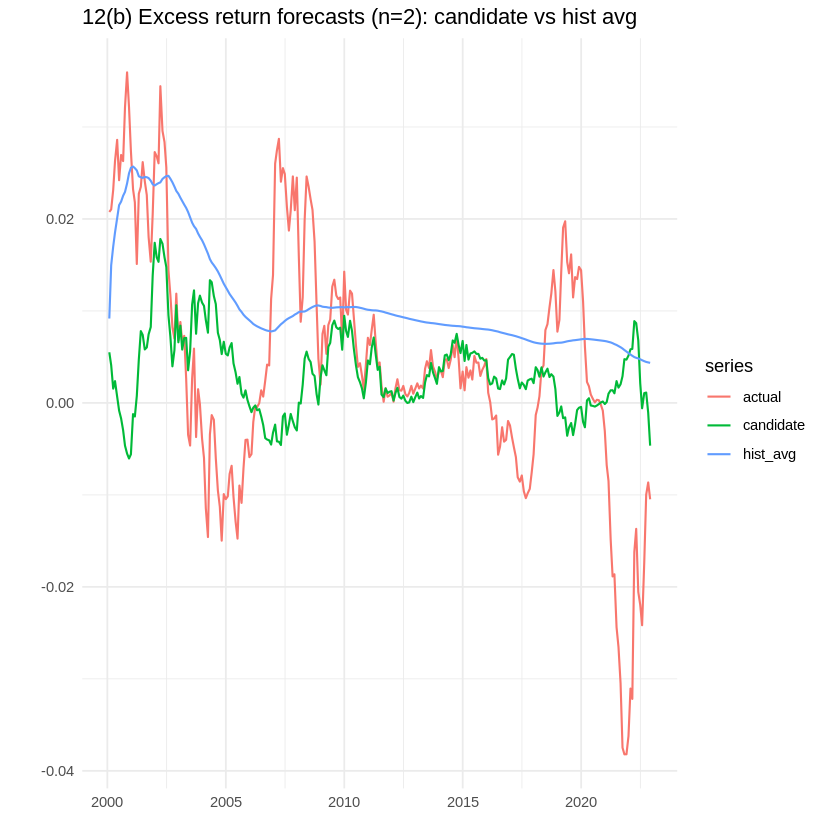

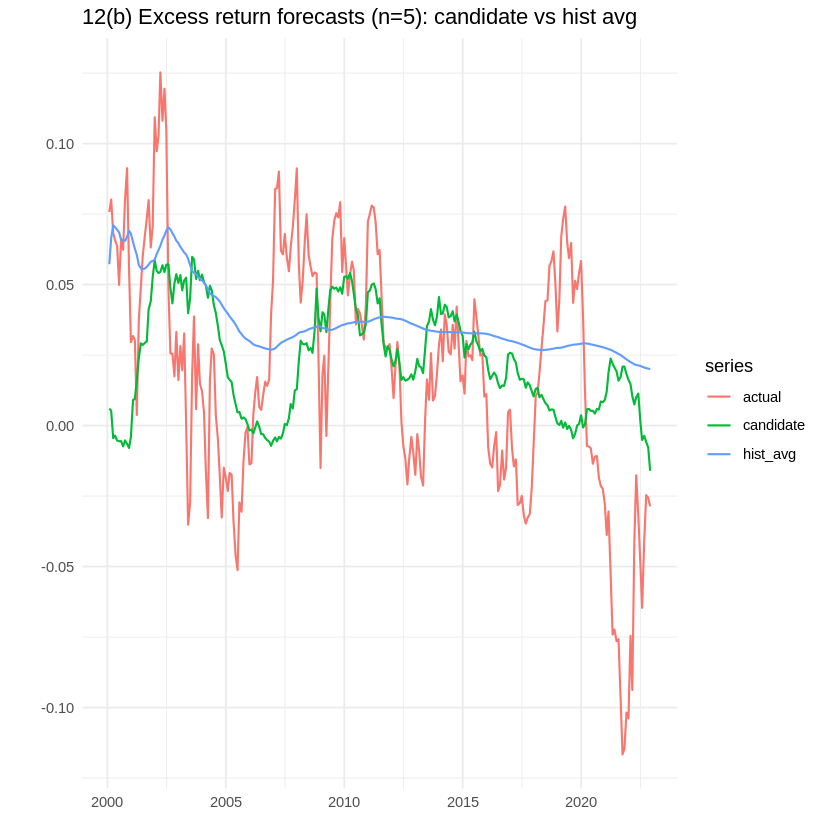

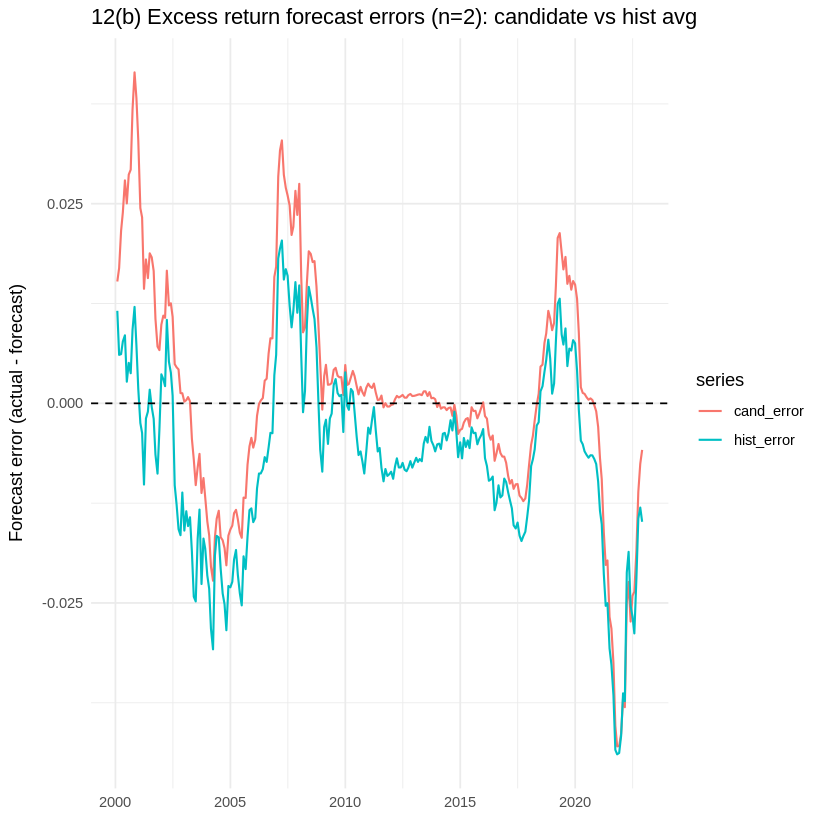


12(c) Out-of-sample R2 (definition given in prompt):

--- Finished all plots above ---
   target alternative       OOS_R2 SSE_candidate SSE_alternative N_used
1 dy(n=2)          EH -0.025149268    0.05589119      0.05452005    276
2 dy(n=2)       RW(0)  0.038194926    0.05589119      0.05811073    276
3 dy(n=5)          EH  0.068255606    0.17710157      0.19007527    240
4 dy(n=5)       RW(0) -0.261035300    0.17710157      0.14044141    240
5 rx(n=2)    hist avg -0.115790313    0.05586244      0.05006536    275
6 rx(n=5)    hist avg  0.008131544    0.51902487      0.52327994    275

================ End Question 12 (aligned) ================


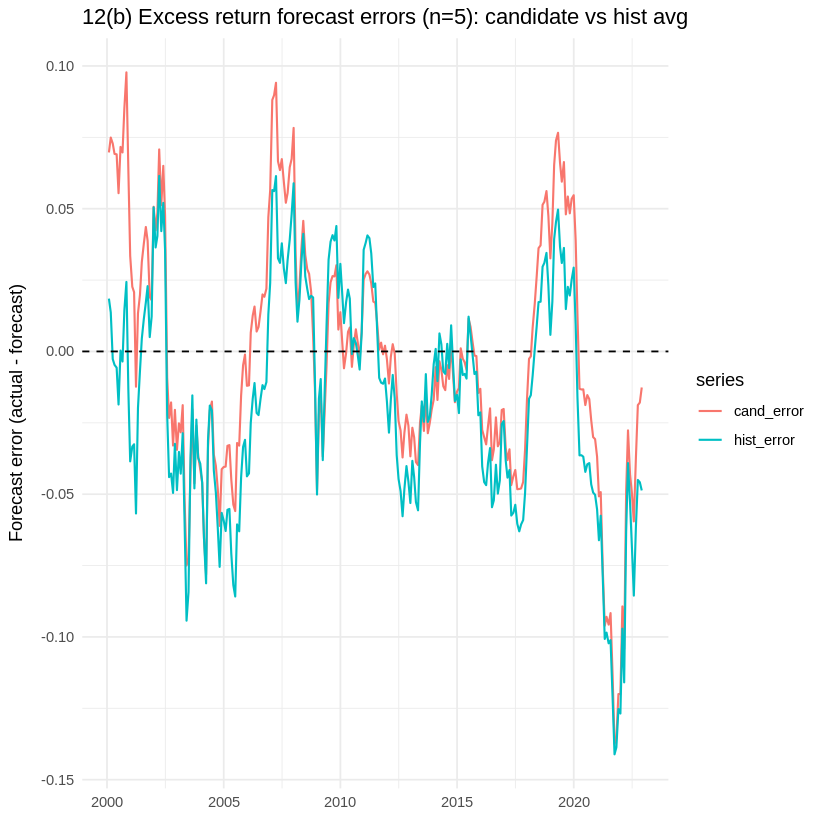

In [ ]:
# ==========================================================
# Q12
# ==========================================================

cat("\n==================== Question 12 ====================\n")

# ---------- Setup / checks ----------
stopifnot(exists("forecast_df"), exists("df2"), exists("SPREAD"))
forecast_df$Date <- as.Date(forecast_df$Date)
df2$Date <- as.Date(df2$Date)

# OOS window (recursive real-time evaluation from 1999-12)
oos_start <- as.Date("1999-12-01")
oos_idx <- which(forecast_df$Date >= oos_start)
cat("OOS evaluation starts at:", as.character(oos_start), "\n")
cat("Number of OOS months (forecast_df):", length(oos_idx), "\n\n")

# ---------- Helper: recursive historical average forecast ----------
expanding_mean_forecast <- function(x) {
  out <- rep(NA_real_, length(x))
  for (t in 2:length(x)) out[t] <- mean(x[1:(t-1)], na.rm = TRUE)
  out
}

# ---------- Helper: OOS R2 per prompt ----------
# OOS R2 = 1 - sum(e_cand^2)/sum(e_alt^2), where e = actual - forecast
oos_r2 <- function(actual, cand_fore, alt_fore, idx) {
  use <- idx[is.finite(actual[idx]) & is.finite(cand_fore[idx]) & is.finite(alt_fore[idx])]
  e_cand <- actual[use] - cand_fore[use]
  e_alt  <- actual[use] - alt_fore[use]
  sse_cand <- sum(e_cand^2)
  sse_alt  <- sum(e_alt^2)
  r2 <- 1 - sse_cand/sse_alt
  list(r2=r2, sse_cand=sse_cand, sse_alt=sse_alt, n=length(use))
}

# ---------- Plot helpers (forecasts & forecast errors time series) ----------
if (!requireNamespace("ggplot2", quietly=TRUE)) install.packages("ggplot2")
if (!requireNamespace("tidyr", quietly=TRUE)) install.packages("tidyr")
library(ggplot2); library(tidyr)

plot_forecast_ts <- function(date, actual, f1, f2, idx, title_txt, f1_name, f2_name) {
  d <- data.frame(Date=date[idx], actual=actual[idx], f1=f1[idx], f2=f2[idx])
  d <- d[complete.cases(d), ]
  names(d) <- c("Date", "actual", f1_name, f2_name)
  d_long <- pivot_longer(d, cols = -Date, names_to="series", values_to="value")
  ggplot(d_long, aes(Date, value, color=series)) +
    geom_line(linewidth=0.6) +
    labs(title=title_txt, x="", y="") +
    theme_minimal()
}

plot_error_ts <- function(date, e1, e2, idx, title_txt, e1_name, e2_name) {
  d <- data.frame(Date=date[idx], e1=e1[idx], e2=e2[idx])
  d <- d[complete.cases(d), ]
  names(d) <- c("Date", e1_name, e2_name)
  d_long <- pivot_longer(d, cols = -Date, names_to="series", values_to="value")
  ggplot(d_long, aes(Date, value, color=series)) +
    geom_line(linewidth=0.6) +
    geom_hline(yintercept=0, linetype="dashed") +
    labs(title=title_txt, x="", y="Forecast error (actual - forecast)") +
    theme_minimal()
}

# ==========================================================
# 12(a) Yield change regression:
# produce time series of forecasts and forecast errors assuming:
#   (a) EH holds, (b) yields follow RW
# ==========================================================

# candidate (regression-based) forecasts and actuals (from your teammate)
dy2_act  <- forecast_df$dy2_actual
dy2_cand <- forecast_df$dy2_forecast
dy5_act  <- forecast_df$dy5_actual
dy5_cand <- forecast_df$dy5_forecast

# Align SPREAD to forecast_df by Date using match (robust)
SPREAD_df <- as.data.frame(SPREAD)
# if SPREAD has its own Date column use it; else assume row-aligned with df2
date_col_candidates <- c("Date","date","DATE","Dates","dates")
dc <- intersect(date_col_candidates, names(SPREAD_df))
SPREAD_dates <- if (length(dc)>=1) as.Date(SPREAD_df[[dc[1]]]) else as.Date(df2$Date)

stopifnot("fs_2" %in% names(SPREAD_df), "fs_5" %in% names(SPREAD_df))
idx_match <- match(forecast_df$Date, SPREAD_dates)
fs2 <- SPREAD_df$fs_2[idx_match]
fs5 <- SPREAD_df$fs_5[idx_match]

# Alternative forecasts required by prompt
# EH: forecasted yield change = forward-spot spread
dy2_eh <- fs2
dy5_eh <- fs5
# RW: forecasted yield change = 0
dy2_rw <- rep(0, length(dy2_act))
dy5_rw <- rep(0, length(dy5_act))

# --- 12(a) Forecast time series (required) ---
print(plot_forecast_ts(forecast_df$Date, dy2_act, dy2_eh, dy2_rw, oos_idx,
                       "12(a) Yield change forecasts (n=2): EH vs RW", "EH", "RW"))
print(plot_forecast_ts(forecast_df$Date, dy5_act, dy5_eh, dy5_rw, oos_idx,
                       "12(a) Yield change forecasts (n=5): EH vs RW", "EH", "RW"))

# --- 12(a) Forecast errors time series (required) ---
# errors for the two alternative models
dy2_err_eh <- dy2_act - dy2_eh
dy2_err_rw <- dy2_act - dy2_rw
dy5_err_eh <- dy5_act - dy5_eh
dy5_err_rw <- dy5_act - dy5_rw

print(plot_error_ts(forecast_df$Date, dy2_err_eh, dy2_err_rw, oos_idx,
                    "12(a) Yield change forecast errors (n=2): EH vs RW", "EH_error", "RW_error"))
print(plot_error_ts(forecast_df$Date, dy5_err_eh, dy5_err_rw, oos_idx,
                    "12(a) Yield change forecast errors (n=5): EH vs RW", "EH_error", "RW_error"))

# ==========================================================
# 12(b) Return regression:
# produce time series of forecasts and forecast errors using
# recursively estimated historical average return
# ==========================================================

rx2_act  <- forecast_df$rx2_actual
rx2_cand <- forecast_df$rx2_forecast
rx5_act  <- forecast_df$rx5_actual
rx5_cand <- forecast_df$rx5_forecast

# Alternative: recursive historical mean
rx2_hist <- expanding_mean_forecast(rx2_act)
rx5_hist <- expanding_mean_forecast(rx5_act)

# --- 12(b) Forecast time series (required) ---
print(plot_forecast_ts(forecast_df$Date, rx2_act, rx2_cand, rx2_hist, oos_idx,
                       "12(b) Excess return forecasts (n=2): candidate vs hist avg", "candidate", "hist_avg"))
print(plot_forecast_ts(forecast_df$Date, rx5_act, rx5_cand, rx5_hist, oos_idx,
                       "12(b) Excess return forecasts (n=5): candidate vs hist avg", "candidate", "hist_avg"))

# --- 12(b) Forecast errors time series (required) ---
rx2_err_cand <- rx2_act - rx2_cand
rx2_err_hist <- rx2_act - rx2_hist
rx5_err_cand <- rx5_act - rx5_cand
rx5_err_hist <- rx5_act - rx5_hist

print(plot_error_ts(forecast_df$Date, rx2_err_cand, rx2_err_hist, oos_idx,
                    "12(b) Excess return forecast errors (n=2): candidate vs hist avg", "cand_error", "hist_error"))
print(plot_error_ts(forecast_df$Date, rx5_err_cand, rx5_err_hist, oos_idx,
                    "12(b) Excess return forecast errors (n=5): candidate vs hist avg", "cand_error", "hist_error"))

# ==========================================================
# 12(c) Compute OOS R2s per prompt definition and interpret later
# Candidate = regression-based forecasts (your model)
# Alternative = EH / RW / historical avg
# ==========================================================

# Yield change: candidate vs EH, candidate vs RW
dy2_r2_eh <- oos_r2(dy2_act, dy2_cand, dy2_eh, oos_idx)
dy2_r2_rw <- oos_r2(dy2_act, dy2_cand, dy2_rw, oos_idx)
dy5_r2_eh <- oos_r2(dy5_act, dy5_cand, dy5_eh, oos_idx)
dy5_r2_rw <- oos_r2(dy5_act, dy5_cand, dy5_rw, oos_idx)

# Returns: candidate vs historical average
rx2_r2_hist <- oos_r2(rx2_act, rx2_cand, rx2_hist, oos_idx)
rx5_r2_hist <- oos_r2(rx5_act, rx5_cand, rx5_hist, oos_idx)

cat("\n12(c) Out-of-sample R2 (definition given in prompt):\n")
oos_table <- data.frame(
  target = c("dy(n=2)","dy(n=2)","dy(n=5)","dy(n=5)","rx(n=2)","rx(n=5)"),
  alternative = c("EH","RW(0)","EH","RW(0)","hist avg","hist avg"),
  OOS_R2 = c(dy2_r2_eh$r2, dy2_r2_rw$r2, dy5_r2_eh$r2, dy5_r2_rw$r2, rx2_r2_hist$r2, rx5_r2_hist$r2),
  SSE_candidate = c(dy2_r2_eh$sse_cand, dy2_r2_rw$sse_cand, dy5_r2_eh$sse_cand, dy5_r2_rw$sse_cand,
                    rx2_r2_hist$sse_cand, rx5_r2_hist$sse_cand),
  SSE_alternative = c(dy2_r2_eh$sse_alt, dy2_r2_rw$sse_alt, dy5_r2_eh$sse_alt, dy5_r2_rw$sse_alt,
                      rx2_r2_hist$sse_alt, rx5_r2_hist$sse_alt),
  N_used = c(dy2_r2_eh$n, dy2_r2_rw$n, dy5_r2_eh$n, dy5_r2_rw$n, rx2_r2_hist$n, rx5_r2_hist$n)
)
cat("\n--- Finished all plots above ---\n")
print(oos_table)
cat("\n================ End Question 12 (aligned) ================\n")